In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from scipy.stats import linregress


import calibration

In [76]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [77]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [78]:
design_matrix.shape

(680, 71)

In [79]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance", 
]

In [80]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    (design_matrix['sofa_score_increase_day2'] > 1) & (design_matrix['sofa_score_increase_day3'] > 1), 1, 0
)
design_matrix_test['future_deterioration'] = np.where(
    (design_matrix_test['sofa_score_increase_day2'] > 1) & (design_matrix_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [81]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])


In [82]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    bootstrap_replace=False,
    bootstrap_fraction=0.9,
    bootstrap_iterations=1000
)
df_estimator.fit(training_data, features=clinical_columns)

# 30-day Mortality

In [83]:
base_col = "Mortality (30-day)"
target_col = "survival_30_day"

testing_data[f'{base_col} Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column=target_col,
    bootstrap=True
)

In [84]:
mort_combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [85]:
mort_bootstrap_counts = calibration.calc_bootstrap_counts(
    mort_combined_results,
    estimator=df_estimator,
    base_col=base_col,
    target_col=target_col,
)

In [86]:
mort_linregress_results = linregress(mort_bootstrap_counts[[f'Estimated {base_col}']].values.ravel(), mort_bootstrap_counts[[f'Actual {base_col}']].values.ravel())

In [87]:
mort_rsquared = mort_linregress_results.rvalue ** 2

In [88]:
mort_predictions = calibration.calc_linregress(
    mort_bootstrap_counts,
    base_col=base_col,
    linregress_results=mort_linregress_results,
)

In [89]:
mort_bootstrap_counts[f'Estimated {base_col}'] = mort_bootstrap_counts[f'Estimated {base_col}'].astype(str)

mort_bootstrap_counts[f'Estimated {base_col}'] = mort_bootstrap_counts[f'Estimated {base_col}'].str[:3]

In [90]:
mort_bootstrap_counts.to_csv(
    "mortality_df.tsv",
    sep="\t",
    index=False
)

In [91]:
mort_combined_results.to_csv(
    "design_matrix_test_mortality_risk.tsv",
    sep="\t"
)

# Sepsis

In [92]:
base_col = "Sepsis"
target_col = "sepsis_or_septic_shock"

testing_data[f'{base_col} Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column=target_col,
    bootstrap=True
)

In [93]:
sepsis_combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [94]:
sepsis_bootstrap_counts = calibration.calc_bootstrap_counts(
    sepsis_combined_results,
    estimator=df_estimator,
    base_col=base_col,
    target_col=target_col,
)

In [95]:
sepsis_linregress_results = linregress(sepsis_bootstrap_counts[[f'Estimated {base_col}']].values.ravel(), sepsis_bootstrap_counts[[f'Actual {base_col}']].values.ravel())

In [96]:
sepsis_rsquared = sepsis_linregress_results.rvalue ** 2

In [97]:
sepsis_predictions = calibration.calc_linregress(
    sepsis_bootstrap_counts,
    base_col=base_col,
    linregress_results=sepsis_linregress_results,
)

In [98]:
sepsis_bootstrap_counts[f'Estimated {base_col}'] = sepsis_bootstrap_counts[f'Estimated {base_col}'].astype(str)

sepsis_bootstrap_counts[f'Estimated {base_col}'] = sepsis_bootstrap_counts[f'Estimated {base_col}'].str[:3]

In [99]:
sepsis_bootstrap_counts.to_csv(
    "sepsis_df.tsv",
    sep="\t",
    index=False
)

In [100]:
sepsis_combined_results.to_csv(
    "design_matrix_test_sepsis_risk.tsv",
    sep="\t"
)

# Infection

In [101]:
base_col = "Infection"
target_col = "verified_infection"

testing_data[f'{base_col} Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column=target_col,
    bootstrap=True
)

In [102]:
infection_combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [103]:
infection_bootstrap_counts = calibration.calc_bootstrap_counts(
    infection_combined_results,
    estimator=df_estimator,
    base_col=base_col,
    target_col=target_col,
)

In [104]:
infection_linregress_results = linregress(infection_bootstrap_counts[[f'Estimated {base_col}']].values.ravel(), infection_bootstrap_counts[[f'Actual {base_col}']].values.ravel())

In [105]:
infection_rsquared = infection_linregress_results.rvalue ** 2

In [106]:
infection_predictions = calibration.calc_linregress(
    infection_bootstrap_counts,
    base_col=base_col,
    linregress_results=infection_linregress_results,
)

In [107]:
infection_predictions = infection_predictions.reset_index(drop=True)

In [108]:
infection_bootstrap_counts[f'Estimated {base_col}'] = infection_bootstrap_counts[f'Estimated {base_col}'].astype(str)

infection_bootstrap_counts[f'Estimated {base_col}'] = infection_bootstrap_counts[f'Estimated {base_col}'].str[:3]

In [109]:
infection_bootstrap_counts.to_csv(
    "infection_df.tsv",
    sep="\t",
    index=False
)

In [110]:
infection_combined_results.to_csv(
    "design_matrix_test_infection_risk.tsv",
    sep="\t"
)

# ICU

In [111]:
base_col = "ICU"
target_col = "critical_care"

testing_data[f'{base_col} Rate'] = df_estimator.predict(
    testing_data[clinical_columns],
    features=clinical_columns,
    target_column=target_col,
    bootstrap=True
)

In [112]:
icu_combined_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

In [113]:
icu_bootstrap_counts = calibration.calc_bootstrap_counts(
    icu_combined_results,
    estimator=df_estimator,
    base_col=base_col,
    target_col=target_col,
)

In [114]:
icu_linregress_results = linregress(icu_bootstrap_counts[[f'Estimated {base_col}']].values.ravel(), icu_bootstrap_counts[[f'Actual {base_col}']].values.ravel())

In [115]:
icu_rsquared = icu_linregress_results.rvalue ** 2

In [116]:
icu_predictions = calibration.calc_linregress(
    icu_bootstrap_counts,
    base_col=base_col,
    linregress_results=icu_linregress_results,
)

In [117]:
icu_bootstrap_counts[f'Estimated {base_col}'] = icu_bootstrap_counts[f'Estimated {base_col}'].astype(str)

icu_bootstrap_counts[f'Estimated {base_col}'] = icu_bootstrap_counts[f'Estimated {base_col}'].str[:3]

In [118]:
icu_bootstrap_counts.to_csv(
    "icu_df.tsv",
    sep="\t",
    index=False
)

In [119]:
icu_combined_results.to_csv(
    "design_matrix_test_icu_risk.tsv",
    sep="\t"
)

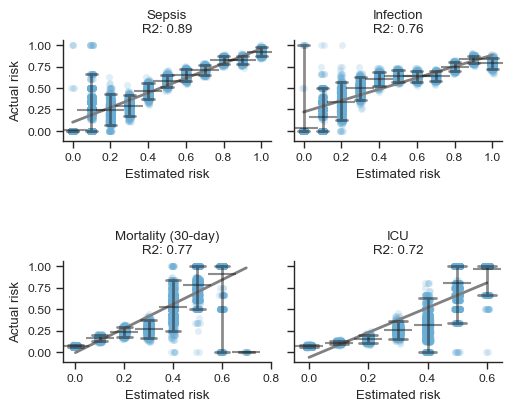

In [120]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    constrained_layout=True,
    #sharex=True,
    sharey=True,
    gridspec_kw={'hspace': 0.25}
)

ax = ax.flatten()

#Sepsis

ax[0].plot(
    sepsis_predictions["x"],
    sepsis_predictions["y"],
    lw=2,
    color="gray",
)

sns.pointplot(
    data=sepsis_bootstrap_counts,
    x="Estimated Sepsis",
    y="Actual Sepsis",
    hue="Estimated Sepsis",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax[0],
    alpha=0.5
)

sns.stripplot(
    data=sepsis_bootstrap_counts,
    x="Estimated Sepsis",
    y="Actual Sepsis",
    #hue="Label",
    ax=ax[0],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)




ax[0].set_title(
    f"Sepsis\nR2: {sepsis_rsquared:.2f}"
)

ax[0].set_xlabel("Estimated risk")
ax[0].set_ylabel("Actual risk")

#Infection

ax[1].plot(
    infection_predictions["x"],
    infection_predictions["y"],
    lw=2,
    color="gray",
)

sns.pointplot(
    data=infection_bootstrap_counts,
    x="Estimated Infection",
    y="Actual Infection",
    hue="Estimated Infection",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax[1],
    alpha=0.5
)

sns.stripplot(
    data=infection_bootstrap_counts,
    x="Estimated Infection",
    y="Actual Infection",
    #hue="Label",
    ax=ax[1],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)




ax[1].set_title(
    f"Infection\nR2: {infection_rsquared:.2f}"
)

ax[1].set_xlabel("Estimated risk")
ax[1].set_ylabel("Actual risk")

#30 day mortality

ax[2].plot(
    mort_predictions["x"],
    mort_predictions["y"],
    lw=2,
    color="gray",
)

sns.pointplot(
    data=mort_bootstrap_counts,
    x="Estimated Mortality (30-day)",
    y="Actual Mortality (30-day)",
    hue="Estimated Mortality (30-day)",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax[2],
    alpha=0.5
)

sns.stripplot(
    data=mort_bootstrap_counts,
    x="Estimated Mortality (30-day)",
    y="Actual Mortality (30-day)",
    #hue="Label",
    ax=ax[2],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)




ax[2].set_title(
    f"Mortality (30-day)\nR2: {mort_rsquared:.2f}"
)

ax[2].set_xlabel("Estimated risk")
ax[2].set_ylabel("Actual risk")

#ICU

ax[3].plot(
    icu_predictions["x"],
    icu_predictions["y"],
    lw=2,
    color="gray",
)

sns.pointplot(
    data=icu_bootstrap_counts,
    x="Estimated ICU",
    y="Actual ICU",
    hue="Estimated ICU",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=ax[3],
    alpha=0.5
)

sns.stripplot(
    data=icu_bootstrap_counts,
    x="Estimated ICU",
    y="Actual ICU",
    #hue="Label",
    ax=ax[3],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.2,
    zorder=1,

)


ax[3].set_title(
    f"ICU\nR2: {icu_rsquared:.2f}"
)

ax[0].set_xticks(
    ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"],
)
ax[1].set_xticks(
    ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"],
)
ax[2].set_xticks(
    ["0.0", "0.2", "0.4", "0.6", "0.8",],
)
ax[3].set_xticks(
    ["0.0", "0.2", "0.4", "0.6",],
)

# ax[3].set_xticklabels(
#     [0.0, 0.2, 0.4, 0.6, 0.8],
# )

ax[3].set_xlabel("Estimated risk")
ax[3].set_ylabel("Actual risk")


ax[0].set_yticks(
    [0.0, 0.25, 0.5, 0.75, 1.0],
)

fig.set_size_inches(
    (5, 4)
)

fig.savefig(
    "calibration.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)